Initial shape: (1564, 21)
Sample columns: Index(['Station Code Unnamed: 0_level_1',
       'Name Of Monitoring Location Unnamed: 1_level_1',
       'State Name Unnamed: 2_level_1', 'Temperature (oC) Unnamed: 3_level_1',
       'Temperature (oC) Unnamed: 4_level_1',
       'Dissolved Oxygen (mg/L) > 5.0 mg/ L',
       'Dissolved Oxygen (mg/L) > 5.0 mg/ L.1', 'pH 6.5 - 8.5',
       'pH 6.5 - 8.5.1', 'Conductivity (µmhos/cm) Unnamed: 9_level_1',
       'Conductivity (µmhos/cm) Unnamed: 10_level_1',
       'Bio-Chemical Oxygen Demand (mg/L) < 3.0 mg/ L'],
      dtype='object')
Renamed ID columns: Index(['Station Code', 'Name Of Monitoring Location', 'State Name',
       'Temperature (oC) Unnamed: 3_level_1',
       'Temperature (oC) Unnamed: 4_level_1'],
      dtype='object')
Shape after cleaning IDs: (1555, 21)
✅ Cleaned numeric values
✅ Created Average columns: ['Temperature AVG', 'Dissolved Oxygen AVG', 'pH 6.5 - 8.5 AVG', 'Conductivity AVG', 'Bio-Chemical Oxygen Demand AVG', 'Nitrate A

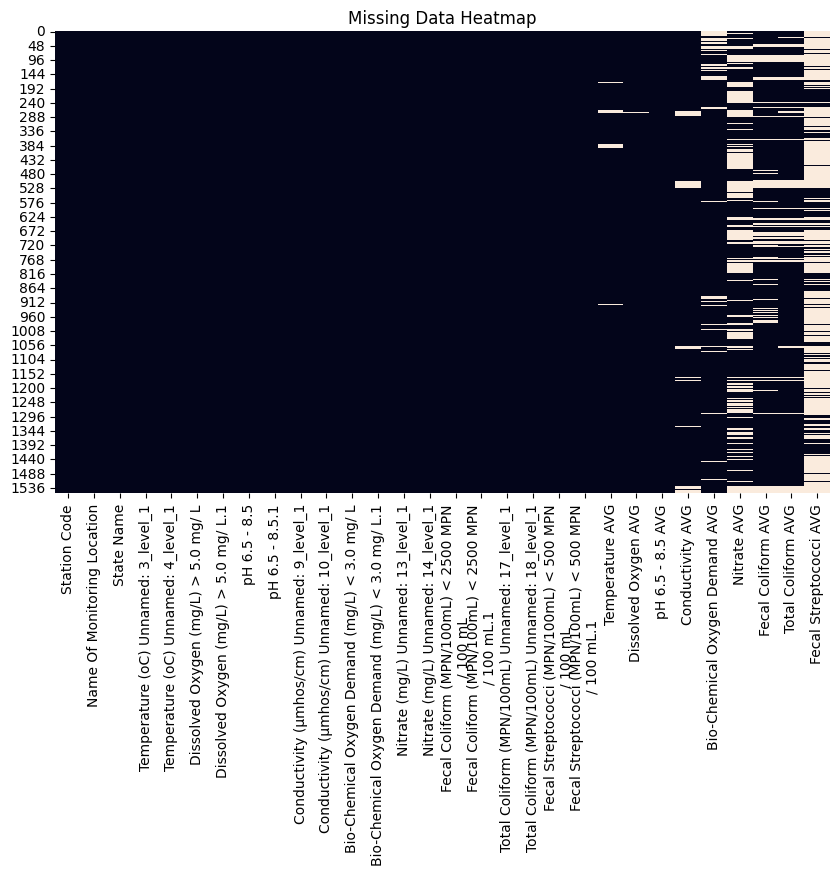

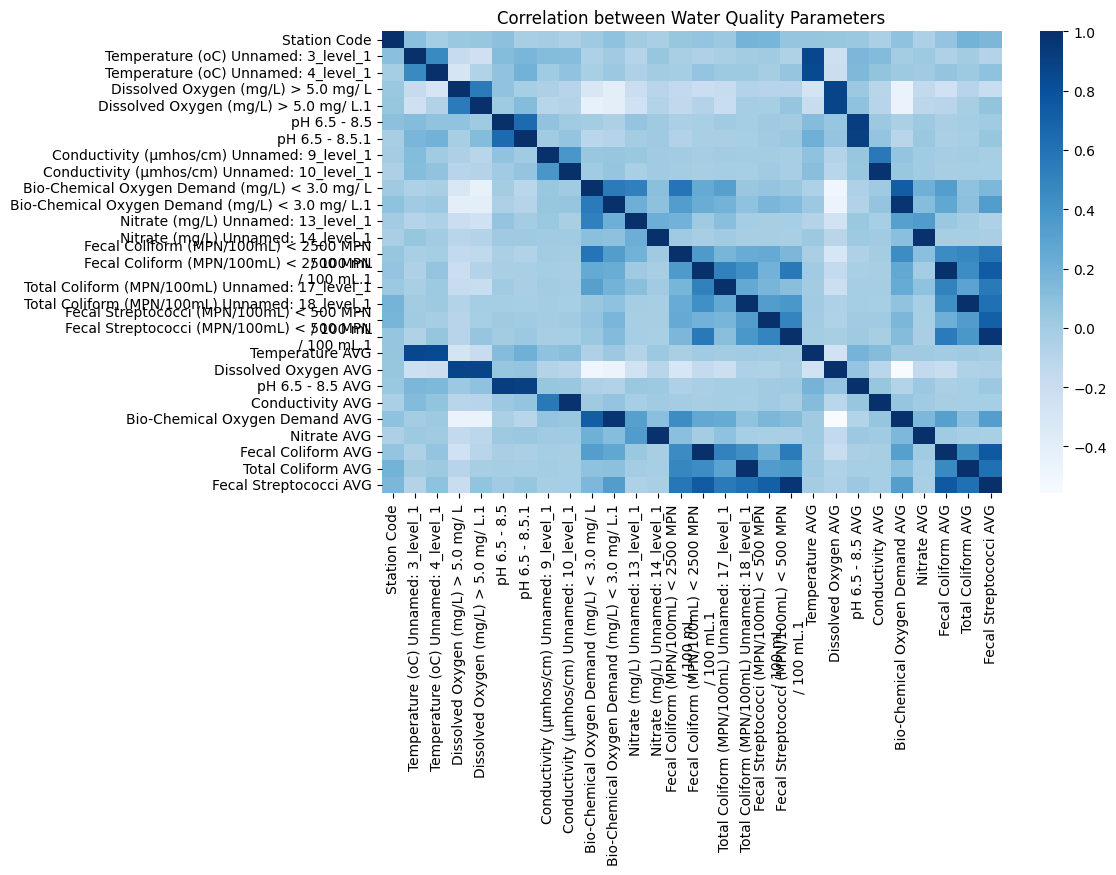

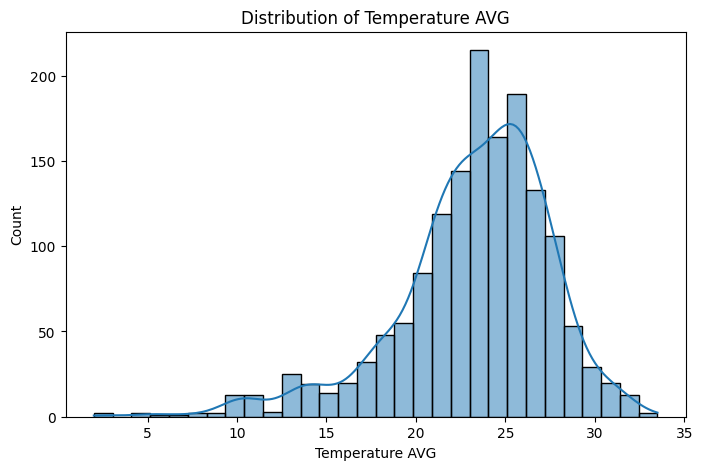

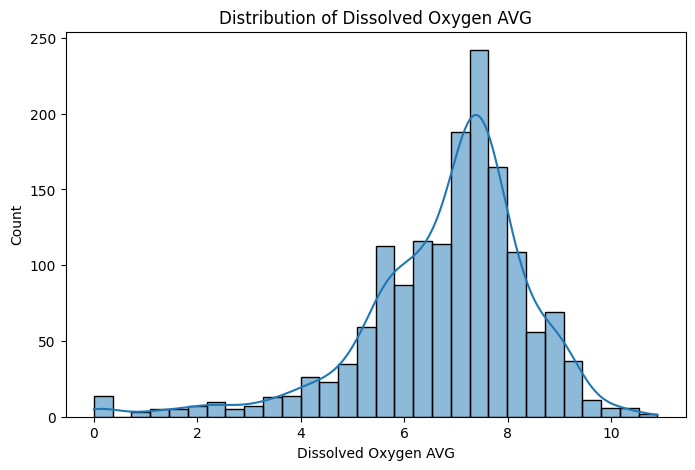

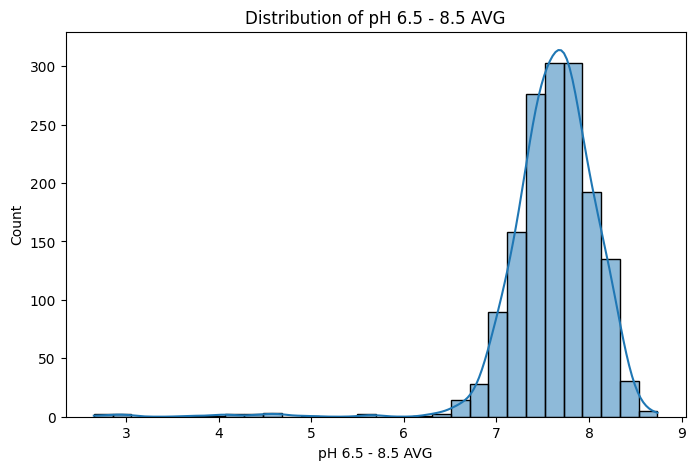

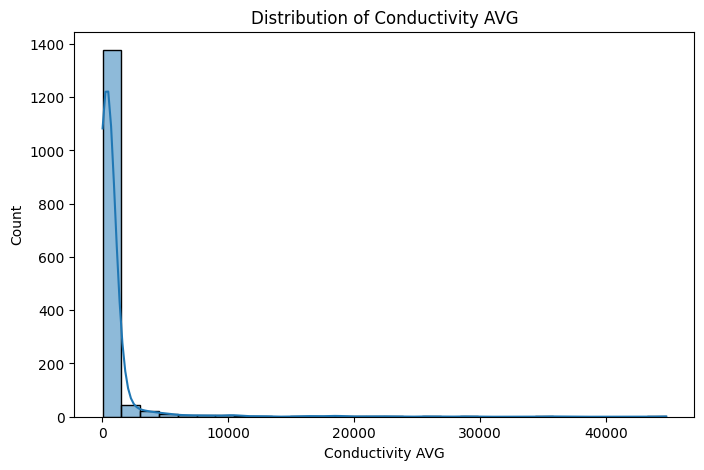

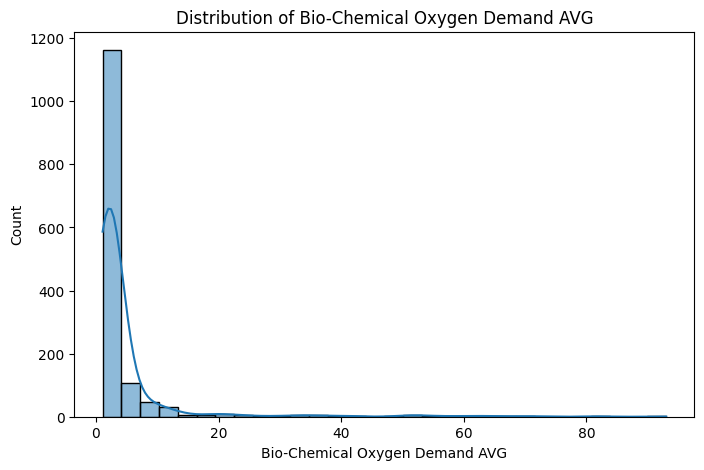

✅ Final cleaned dataset saved as cleaned_data.csv


In [10]:
# ============================================================
# STEP 1: Import Libraries
# ============================================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

# ============================================================
# STEP 2: Load Excel with Multi-Row Header
# ============================================================
file_path = "/content/WQuality_River-Data-2022 (1).xlsx"   # <-- your updated Excel file

# Read first 2 rows as headers (main name + MIN/MAX)
df = pd.read_excel(file_path, header=[0,1])

# Flatten multi-level headers → "Parameter MIN" / "Parameter MAX"
df.columns = [' '.join([str(c1), str(c2)]).strip() for c1, c2 in df.columns.values]

print("Initial shape:", df.shape)
print("Sample columns:", df.columns[:12])

# ============================================================
# STEP 3: Fix ID Column Names
# ============================================================
df.rename(columns={
    df.columns[0]: "Station Code",
    df.columns[1]: "Name Of Monitoring Location",
    df.columns[2]: "State Name"
}, inplace=True)

print("Renamed ID columns:", df.columns[:5])

# Drop rows where Station Code is missing (if any)
df = df[df["Station Code"].notna()].reset_index(drop=True)

print("Shape after cleaning IDs:", df.shape)

# ============================================================
# STEP 4: Clean Numeric Values
# ============================================================
def clean_numeric(x):
    if isinstance(x, str):
        x = x.strip()
        if "BDL" in x:   # Below Detection Limit
            return np.nan
        try:
            return float(x)
        except:
            return np.nan
    return x

# Identify numeric columns (exclude ID cols)
id_cols = ["Station Code", "Name Of Monitoring Location", "State Name"]
numeric_cols = [c for c in df.columns if c not in id_cols]

for col in numeric_cols:
    df[col] = df[col].apply(clean_numeric)

df[numeric_cols] = df[numeric_cols].astype(float)

print("✅ Cleaned numeric values")

# ============================================================
# STEP 5: Create Average Columns (Fixed)
# ============================================================

# Identify parameter columns (exclude ID columns)
id_cols = ["Station Code", "Name Of Monitoring Location", "State Name"]
param_cols = [c for c in df.columns if c not in id_cols]

# Loop over pairs of columns (MIN/MAX) and create AVG
for i in range(0, len(param_cols), 2):  # step by 2
    col_min = param_cols[i]
    col_max = param_cols[i+1]

    # Derive base name (strip units & extra text)
    base_name = col_min.split("(")[0].strip()

    # Create average column
    avg_col = base_name + " AVG"
    df[avg_col] = (df[col_min] + df[col_max]) / 2

print("✅ Created Average columns:", [c for c in df.columns if "AVG" in c])


# ============================================================
# STEP 6: Handle Missing Values
# ============================================================
df = df.dropna(subset=["Station Code", "State Name"])   # drop rows missing IDs
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())  # fill numeric NaN with mean

print("Shape after handling missing values:", df.shape)

# ============================================================
# STEP 7: Exploratory Data Analysis (EDA)
# ============================================================

# --- Missing Data Heatmap ---
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Data Heatmap")
plt.show()

# --- Correlation Matrix ---
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), cmap="Blues")
plt.title("Correlation between Water Quality Parameters")
plt.show()

# --- Distribution of Key Parameters (use AVG) ---
parameters = [c for c in df.columns if "AVG" in c]
for param in parameters[:5]:  # just first 5 for demo
    plt.figure(figsize=(8,5))
    sns.histplot(df[param], bins=30, kde=True)
    plt.title(f"Distribution of {param}")
    plt.show()

# --- Example: State-wise Average BOD ---
bod_cols = [c for c in df.columns if "BOD" in c.upper() and "AVG" in c.upper()]
if bod_cols:
    bod_col = bod_cols[0]
    plt.figure(figsize=(12,6))
    sns.barplot(x="State Name", y=bod_col, data=df, ci=None, palette="viridis")
    plt.xticks(rotation=90)
    plt.title(f"Average {bod_col} by State")
    plt.show()

# ============================================================
# STEP 8: Save Cleaned Data
# ============================================================
df.to_csv("cleaned_data.csv", index=False)
print("✅ Final cleaned dataset saved as cleaned_data.csv")
